In [1]:
import os
import sys
import random
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import mlflow

import tensorflow as tf
from tensorflow.keras import Model, Sequential, layers
from tensorflow.keras.layers import Input, concatenate, Conv2D, MaxPooling2D, Conv2DTranspose, Flatten 

2026-03-26 15:50:28.210726: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774536628.233125      73 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774536628.240696      73 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774536628.258254      73 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774536628.258283      73 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774536628.258298      73 computation_placer.cc:177] computation placer alr

In [2]:
sys.stderr = open(os.devnull, "w")

I0000 00:00:1774536645.016164      73 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46640 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1774536725.627781      73 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-26 15:52:56.289356: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
E0000 00:00:1774536915.319969      73 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-03-26 15:55:51.065457: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-26 15:56:29.844853: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_R

# Dataloading

In [ ]:
notebook_dir = Path().resolve() 
parent_dir = notebook_dir.parent
sys.path.insert(0, str(parent_dir))

from Data.DataLoader_pkl import DataLoader_pkl
from Data.DataGenerator import DataGenerator
from Helpers import Helpers
Helpers = Helpers()

from utils.augmentations import PromptUNetAugmenter
augmenter = PromptUNetAugmenter()

In [4]:
datagenerator = DataGenerator(DataLoader_pkl(["Data/training_combined_gpuNet.pkl", "Data/training_combined_totalSeg.pkl", "Data/training_medDec.pkl"], val_size=0.015))


Loading PKL dataset(s)…
Loaded 61 PIDs from /home/dpxuser/Data/training_combined_gpuNet.pkl
Loaded 45 PIDs from /home/dpxuser/Data/training_combined_totalSeg.pkl
Loaded 40 PIDs from /home/dpxuser/Data/training_medDec.pkl

Final dataset size: 146 patients.



# Prompt U-Net

In [10]:
batch_size = 128
dp_training = 3500 # be careful, these variables exist twice

steps_per_epoch = dp_training // batch_size  
decay_epochs = 1800  # reduce every x epochs
decay_steps = steps_per_epoch * decay_epochs 

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=decay_steps,  # decay every x epochs
    decay_rate=0.85,                      # halve LR each decay
    staircase=True
)

In [ ]:
class PromptUNet():

    def __init__(self):
        self.loss = tf.losses.binary_crossentropy
        self.train_loss = tf.keras.metrics.Mean(name='train_loss')

        self.this = self.build()


    def build(self):
        inputs = [tf.keras.Input(shape=(datagenerator.height, datagenerator.width, 1),name='image'),
                tf.keras.Input(shape=(datagenerator.height, datagenerator.width, 2),name='prompt')]      # u(x, [x+i, y+i]) = y      i = shift (e.g. 3)      [x+i, y+i] = prompt

        image = inputs[0]
        prompt = inputs[1]

        prompt_skip_connections = []
        skip_connections = []


        def conv_block(inp, filters, padding='same', activation='leaky_relu', dropout_rate=0.1, **kwargs):
            """
            Convolution block of UNet encoder
            """
            inp = layers.Conv2D(filters, (3,3), padding=padding, **kwargs)(inp)
            inp = layers.BatchNormalization()(inp)
            inp = layers.LeakyReLU()(inp)
            inp = layers.Dropout(dropout_rate)(inp)
            return inp

        def conv_block_prompt(x, p, filters, padding='same', activation='leaky_relu', dropout_rate=0.1):           
            """
            Convolution block of UNet encoder with conditioning on prompt
            """
            p = conv_block(p, filters)
            x = layers.Conv2D(filters, (3, 3), padding=padding)(x)
            x = layers.Add()([x,p])
            x = layers.Dropout(dropout_rate)(x)
            return x

        def conv_block_up(inp, filters, padding='same', activation='leaky_relu', dropout_rate=0.1, **kwargs):
            """
            Convolution block of UNet encoder
            """
            inp = layers.BatchNormalization()(inp)
            inp = layers.LeakyReLU()(inp)
            inp = layers.Dropout(dropout_rate)(inp)
            inp = Conv2DTranspose(filters, (3,3), padding=padding, **kwargs)(inp)
            return inp

    # ---------------------------------------------- 

        def encoder_block(p, filters, padding='same', activation='leaky_relu'):
            """
            Encoding of prompt
            """
            print("p encode shape:", p.shape)
            p = conv_block(p, filters, padding, activation)
            p = conv_block(p, filters, padding, activation)
            prompt_skip_connections.append(p)
            p = conv_block(p, filters*2, padding, strides=2)
            return p

        def encoder_block_2(x, p, filters, padding='same'):
            """Encoding of x / input image + Conditioning on prompt
            """
            print("x,p shape:", x.shape, p.shape)
            x = conv_block_prompt(x, p, filters)        
            skip_connections.append(x)
            x = conv_block(x, filters*2, padding, strides=2) # Strided conv better then max pooling
            return x

        def decoder_block(inp, concat_layer, filters, padding='same', dropout_rate=0.1):
            """Upsample the feature maps + skip connections
            """
            x = conv_block_up(inp, filters, padding, strides=2)
            print("x,concat shape:", x.shape, concat_layer.shape)
            x = conv_block(x, filters, padding, dropout_rate=dropout_rate)
            x = concatenate([x,concat_layer])      
            x = conv_block(x, filters, padding, dropout_rate=dropout_rate)
            return x


        # --- Encoding prompt ---
        print("--- Encoding prompt ---")
        prompt = Conv2D(32, (3, 3), padding="same")(prompt)
        prompt = encoder_block(prompt,32)
        prompt = encoder_block(prompt,64)
        prompt = encoder_block(prompt,128)
        prompt = encoder_block(prompt,256)
        prompt = encoder_block(prompt,512)
        print()
        print("p encode shape:", prompt.shape, "\n\n")

        # --- Enprompt_skip_connectionsx (with conditioning on prompt) ---
        print("--- Encoding x (with conditioning on prompt) ---")
        x = Conv2D(32, (3, 3), padding="same")(image)
        x = encoder_block_2(x=x, p=prompt_skip_connections.pop(0), filters=32) 
        x = encoder_block_2(x, prompt_skip_connections.pop(0), 64)
        x = encoder_block_2(x, prompt_skip_connections.pop(0), 128)
        x = encoder_block_2(x, prompt_skip_connections.pop(0), 256)
        x = encoder_block_2(x, prompt_skip_connections.pop(0), 512)

        # --- Middle part ---
        print()
        x = conv_block(x, 1024, dropout_rate=0.2)  # Höhere Dropout-Rate im Bottleneck
        print("--- Middle part (not in skip connection) ---")
        print("x shape:", x.shape, "\n\n")
        

        # --- Decoding / Upsampling (with skip connections) ---
        print("--- Decoding / Upsampling (with skip connections) ---") 
        x = decoder_block(x, skip_connections.pop(), 512)
        x = decoder_block(x, skip_connections.pop(), 256)
        x = decoder_block(x, skip_connections.pop(), 128)
        x = decoder_block(x, skip_connections.pop(), 64)
        x = decoder_block(x, skip_connections.pop(), 32)
        print("x shape:", x.shape)


        output = Conv2D(1, 1)(x)                               
        output = tf.keras.activations.sigmoid(output)          

        return tf.keras.Model(inputs=inputs, outputs=output)



    # Doing one training step
    @tf.function # graph mode instead of eager
    def train_step(self,z):
        with tf.GradientTape() as tape:
            # z shape: (input[batch_size,height,width,1], label[batch_size,height,width,1], prompt[batch_size,height,width,2])
            # 0 = input/x, 1 = label/y, 2 = prompt/p
            y_pred = self.this([z[0], z[2]], training=True)   
            loss = self.loss(z[1], y_pred)

        gradients = tape.gradient(loss, self.this.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.this.trainable_variables))
        # self.train_loss(loss)
        self.train_loss.update_state(loss)

    # One training epoch
    def train_epoch(self, train_dataset, M=5, batch_size=32):
        """train_dataset = (x_train[num_slices,height,width,1], y_train[num_slices,height,width,1], p_train[num_slices,height,width,2]). Tuple, no list!
        """
        train_dataset = train_dataset.shuffle(256) \
        .map(augmenter, num_parallel_calls=tf.data.AUTOTUNE) \
        .batch(batch_size) \
        .prefetch(tf.data.AUTOTUNE)

        for _ in range(M):
            # Let TF handle the iteration natively
            for z in train_dataset:
                self.train_step(z)
                print(".", end='')
            print() # newline after each epoch

        
# init model
model = PromptUNet()
model.optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

dummy_input = tf.random.uniform([1, datagenerator.height, datagenerator.width, 1])
dummy_prompt = tf.random.uniform([1, datagenerator.height, datagenerator.width, 2])
_ = model.this([dummy_input, dummy_prompt])


# (batchsize, heigt, width, channels -> image and label for prompt (2), otherwise only image (1))

--- Encoding prompt ---
p encode shape: (None, 128, 128, 32)
p encode shape: (None, 64, 64, 64)
p encode shape: (None, 32, 32, 128)
p encode shape: (None, 16, 16, 256)
p encode shape: (None, 8, 8, 512)

p encode shape: (None, 4, 4, 1024) 


--- Encoding x (with conditioning on prompt) ---
x,p shape: (None, 128, 128, 32) (None, 128, 128, 32)
x,p shape: (None, 64, 64, 64) (None, 64, 64, 64)
x,p shape: (None, 32, 32, 128) (None, 32, 32, 128)
x,p shape: (None, 16, 16, 256) (None, 16, 16, 256)
x,p shape: (None, 8, 8, 512) (None, 8, 8, 512)

--- Middle part (not in skip connection) ---
x shape: (None, 4, 4, 1024) 


--- Decoding / Upsampling (with skip connections) ---
x,concat shape: (None, 8, 8, 512) (None, 8, 8, 512)
x,concat shape: (None, 16, 16, 256) (None, 16, 16, 256)
x,concat shape: (None, 32, 32, 128) (None, 32, 32, 128)
x,concat shape: (None, 64, 64, 64) (None, 64, 64, 64)
x,concat shape: (None, 128, 128, 32) (None, 128, 128, 32)
x shape: (None, 128, 128, 32)


# Training

In [ ]:
epochs = 5000
batch_size = 128

offset = 12
max_number_labels = 4
cropping = True
# cropping_composition = 0.7
cropping_composition = 1.0
min_crop_size = 0.5

dp_training = 3500
dp_testing = 1000

new_ds = 75 # Every x Epochs a new DS is generated
new_val_loop = 300 # Every x Epochs the validation loop is performed

version = 'p_unet_273'

Creating new Data Points ...
It took 48 seconds


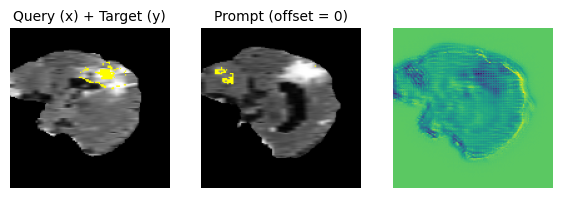

Creating new Data Points ...
It took 113 seconds
............................
Epoch 1, Loss: 0.2910928428173065, 
............................
Epoch 2, Loss: 0.1812862753868103, 
............................
Epoch 3, Loss: 0.15000484883785248, 
............................
Epoch 4, Loss: 0.13505706191062927, 
............................
Epoch 5, Loss: 0.12476810067892075, 
............................
Epoch 6, Loss: 0.1177985742688179, 
............................
Epoch 7, Loss: 0.11770237237215042, 
............................
Epoch 8, Loss: 0.11111009120941162, 
............................
Epoch 9, Loss: 0.10952435433864594, 
............................
Epoch 10, Loss: 0.1118645891547203, 
............................
Epoch 11, Loss: 0.10756625235080719, 
............................
Epoch 12, Loss: 0.10437760502099991, 
............................
Epoch 13, Loss: 0.10318837314844131, 
............................
Epoch 14, Loss: 0.10165723413228989, 
..........................

In [ ]:
from IPython.display import clear_output

def fit(epochs):
    mlflow.set_experiment(version)

    with mlflow.start_run() as run:
        
        # Log hyperparameters
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("max_number_labels", max_number_labels)
        mlflow.log_param("num_epochs", epochs)
        mlflow.log_param("loss_function", "binary_crossentropy")
        
        test_ds, _ = datagenerator.get_val_data_points(max_data_points=dp_testing, offset=offset, max_number_labels=max_number_labels, cropping=False)
        len_test_ds = len(list(test_ds.as_numpy_iterator()))
        
        
        for epoch in range(epochs):  
            # --- Log Lr ---
            current_lr = model.optimizer.learning_rate
            
            if isinstance(current_lr, tf.keras.optimizers.schedules.LearningRateSchedule):
                current_lr = current_lr(epoch)  # evaluate schedule at current epoch
            else:
                current_lr = current_lr.numpy()  # constant value

            mlflow.log_metric("learning_rate", float(current_lr), step=epoch)
            
            model.train_loss.reset_state()

            if epoch%8==0 and epoch != 0:
                
                model_name = f'{version}.keras'
                model.this.save(model_name)
                #mlflow.log_artifact(model_name, artifact_path="checkpoints")
                
            # Validation Loop
            if epoch%new_val_loop==0 and epoch != 0:
                
                total_dice = 0

                for x_test, y_test, p_test in test_ds:
                    x_test = tf.expand_dims(x_test, axis=0) 
                    p_test = tf.expand_dims(p_test, axis=0)

                    val_pred = model.this([x_test[0:1,:,:,0:1], p_test[0:1,...]])
                    total_dice += Helpers.dice_score_tf(y_test[...,0:1], val_pred)

                total_dice /= len_test_ds
                mlflow.log_metric("validation_loss", 1-total_dice, step=epoch)
                print('Validation loss:', str(1-total_dice))

                
                
            # Pull new random Train Dataset (every x epochs because create_prompt takes some time)
            if epoch%new_ds==0:
                
                # Plot pred for first x examples of val ds
                x_test, y_test, p_test = next(iter(test_ds))
                x_test = tf.expand_dims(x_test, axis=0) 
                p_test = tf.expand_dims(p_test, axis=0)

                pred = model.this([x_test[0:1,:,:,0:1], p_test[0:1,...]])
                Helpers.plot_result(x_test, y_test, p_test, pred, 0, "")
                
                # New Ds
                train_ds, offset_train = datagenerator.get_data_points(max_data_points=dp_training, offset=offset, max_number_labels=max_number_labels, 
                                                                       cropping=cropping, min_crop_size=min_crop_size, cropping_composition=cropping_composition)
                   
                    
            model.train_epoch(train_dataset=train_ds, M=1, batch_size=batch_size)      

            # Display & log metrics at the end of each epoch
            print(f'Epoch {epoch + 1}, '
                  f'Loss: {model.train_loss.result()}, ')
            mlflow.log_metric("train_loss", model.train_loss.result(), step=epoch)
            
        # log the final model
        # mlflow.keras.log_model(model.this, artifact_path="final_model")

fit(epochs)   